### Exploratory Data Analysis
Exploring data from different tables from mysql to find patterns for the business insights

In [1]:
# connect to mysql
import pandas as pd
import os
import sqlalchemy as sqla
from dotenv import load_dotenv
from urllib.parse import quote_plus
import matplotlib.pyplot as plt
import seaborn as sns

# to load the .env file load_dotenv is used here
load_dotenv('../.env')

# all the credentials loaded from the .env file
username=os.getenv('DB_USER')
pwd=os.getenv('DB_PASSWORD')
host=os.getenv('DB_HOST')
port=os.getenv('DB_PORT')
db= os.getenv('DB_NAME')

# quote_plus encodes the password so that any special characters in password can't break url
safe_pwd=quote_plus(pwd)

# connection url
url='mysql+pymysql://'+username+':'+safe_pwd+'@'+host+':'+port

db_con=sqla.create_engine(url+'/'+db)

In [6]:
#loading order_features to check proper connection
order_f=pd.read_sql("select * from order_features",db_con)
order_f.shape, order_f.dtypes

((99441, 7),
 order_id                            object
 customer_id                         object
 order_status                        object
 order_purchase_timestamp    datetime64[ns]
 delivery_days                      float64
 delivery_delay                     float64
 order_value                        float64
 dtype: object)

#### 1. Univariate & Distribution Analysis
Looking at one column at a time to understand its shape, values distribution, skew

##### 1.1 Order_value distribution

In [ ]:
# Checking the distribution of data
order_f['order_value'].describe()

count    98666.000000
mean       160.577638
std        220.466087
min          9.590000
25%         61.980000
50%        105.290000
75%        176.870000
max      13664.080000
Name: order_value, dtype: float64

In [9]:
# Checking the skewness of data
order_f['order_value'].skew()

np.float64(9.227552388254525)

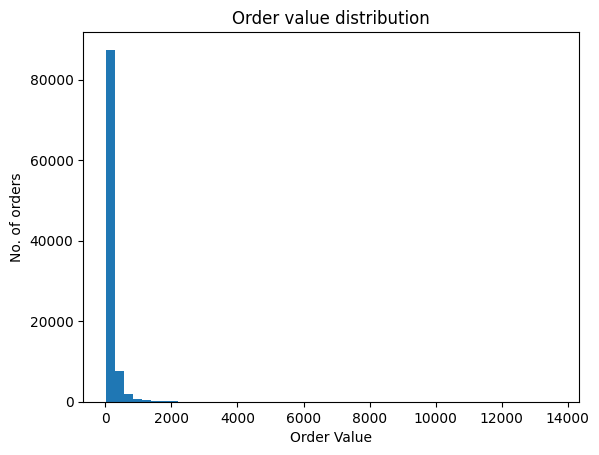

In [10]:
# Creating histogram for order_value
values=order_f['order_value'].dropna()

plt.hist(values, bins=50)
plt.xlabel('Order Value')
plt.ylabel('No. of orders')
plt.title('Order value distribution')
plt.show()

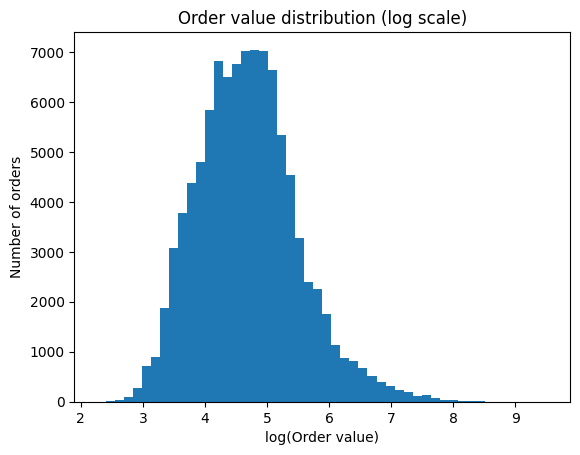

In [11]:
import numpy as np
plt.hist(np.log(values), bins=50)
plt.xlabel('log(Order value)')
plt.ylabel('Number of orders')
plt.title('Order value distribution (log scale)')
plt.show()

**Observations:**
1. Order value is right-skewed (skew = 9.23) becuase of this, mean (160.58) is higher than median (105.29).
2. Half of all orders are between 62 and 177, while the maximum is 13,664 which means most of the orders are low value purchases.
3. Because of skewness, it is better to use median while comparison.
4. So in business, revenue here depends on high order volumes, which needs to be maximized.

##### 1.2 Order Status

In [18]:
# checking order_status value count
status_counts= order_f['order_status'].value_counts()
status_counts

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

In [19]:
# checking % of each value_counts
(order_f['order_status'].value_counts(normalize=True)*100).round(2)

order_status
delivered      97.02
shipped         1.11
canceled        0.63
unavailable     0.61
invoiced        0.32
processing      0.30
created         0.01
approved        0.00
Name: proportion, dtype: float64

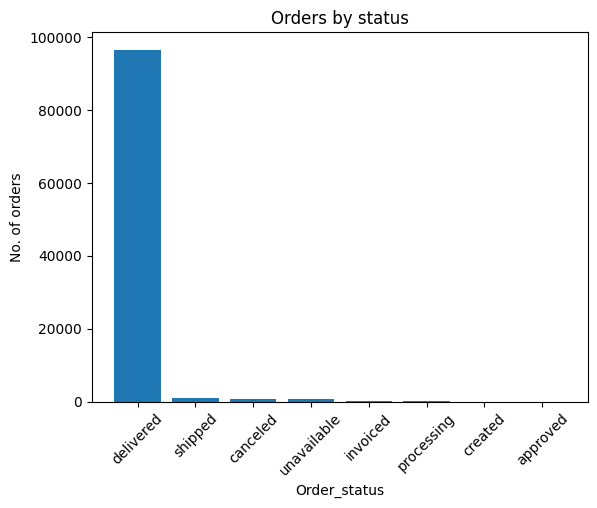

In [28]:
# Creating bar chart for orders by status
plt.bar(status_counts.index,status_counts.values)
plt.xlabel('Order_status')
plt.ylabel('No. of orders')
plt.title('Orders by status')
plt.xticks(rotation=45)
plt.show()

**Observations:**
1. Here 97% of the orders are delivered means most orders completed successfully.
2. Using delivered orders for delivery analysis is valid because others don't have delivery date.

#### 1.3 Review Score

In [17]:
# Loading reviews table
reviews= pd.read_sql("select * from order_reviews",db_con)


In [22]:
# checking review score mean
reviews['review_score'].mean()

np.float64(4.08642062404257)

In [25]:
# checking review score value counts
score_counts= reviews['review_score'].value_counts().sort_index()
score_counts

review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64

In [27]:
# checking review score percentage
(reviews['review_score'].value_counts(normalize=True)*100).round(2).sort_index()

review_score
1    11.51
2     3.18
3     8.24
4    19.29
5    57.78
Name: proportion, dtype: float64

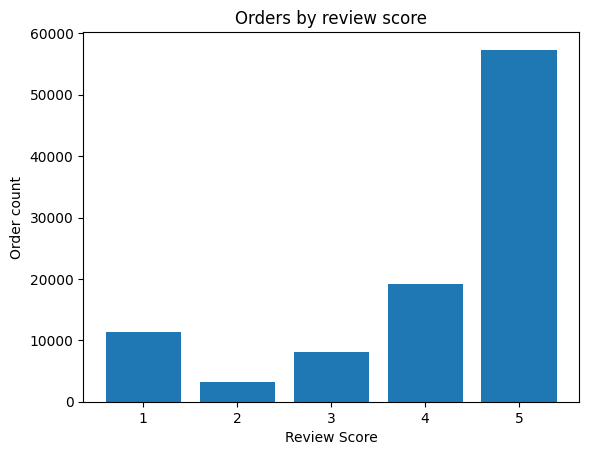

In [30]:
# Plotting reviews bar chart for review_score
plt.bar(score_counts.index,score_counts.values)
plt.xlabel('Review Score')
plt.ylabel('Order count')
plt.title('Orders by review score')
plt.show()

**Observations:**
1. More than 75% of the customers are statisfied with the delivery and gave rating 4 or 5.
2. Mean rating is more than 4 out of 5.
3. But around 11% of the customers are not satisfied and it needs to be investigated. It could be because of delivery delay.

#### 1.4 Delivery days and on-time vs late

In [33]:
# Keeping only delivered dates
delivered=order_f.dropna(subset=['delivery_days','delivery_delay'])
delivered.shape

(96476, 7)

In [34]:
# delivered days summary
delivered['delivery_days'].describe()

count    96476.000000
mean        12.094086
std          9.551746
min          0.000000
25%          6.000000
50%         10.000000
75%         15.000000
max        209.000000
Name: delivery_days, dtype: float64

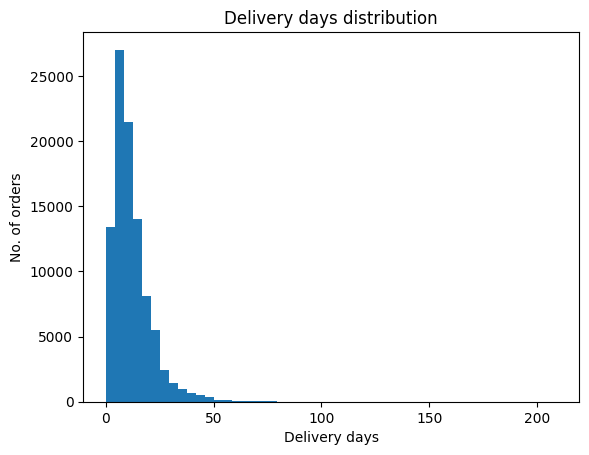

In [35]:
plt.hist(delivered['delivery_days'],bins=50)
plt.xlabel('Delivery days')
plt.ylabel('No. of orders')
plt.title('Delivery days distribution')
plt.show()

In [38]:
# on-time vs late
# checking late delivery counts
is_late=delivered['delivery_delay']>0
late_counts=is_late.value_counts()
late_counts

delivery_delay
False    89941
True      6535
Name: count, dtype: int64

In [39]:
# checking late delivery percentages
(is_late.value_counts(normalize=True)*100).round(2)

delivery_delay
False    93.23
True      6.77
Name: proportion, dtype: float64

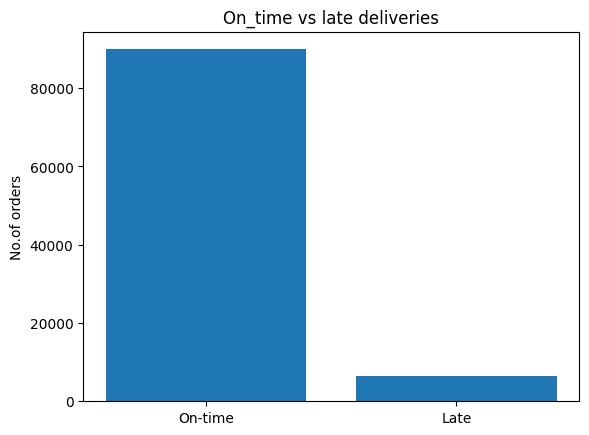

In [40]:
plt.bar(['On-time','Late'],[late_counts[False], late_counts[True]])
plt.ylabel('No.of orders')
plt.title('On_time vs late deliveries')
plt.show()

**Observations:** 
1. Median Delivery time is 10 days.
2. Less than 7% orders are delayed.
3. Most of the orders are delivered on time. But very few orders took very long which needs to be investigated.
4. This on time vs delay orders needs to be compared with review score in bivariate analysis.  

#### Repeat customer & Top sellers

In [41]:
# Reading customer_summary and Seller_summary tables
cust_sum= pd.read_sql("select * from customer_summary",db_con)
seller_sum=pd.read_sql("select * from seller_summary",db_con)
cust_sum.shape,seller_sum.shape

((95420, 5), (3095, 3))

In [43]:
# checking repeat customer counts: 0 means not repeated 1 means repeated
repeat_counts= cust_sum['is_repeat'].value_counts().sort_index()
repeat_counts

is_repeat
0    92507
1     2913
Name: count, dtype: int64

In [44]:
# checking repeat customer percentages
(cust_sum['is_repeat'].value_counts(normalize=True)*100).round(2)

is_repeat
0    96.95
1     3.05
Name: proportion, dtype: float64

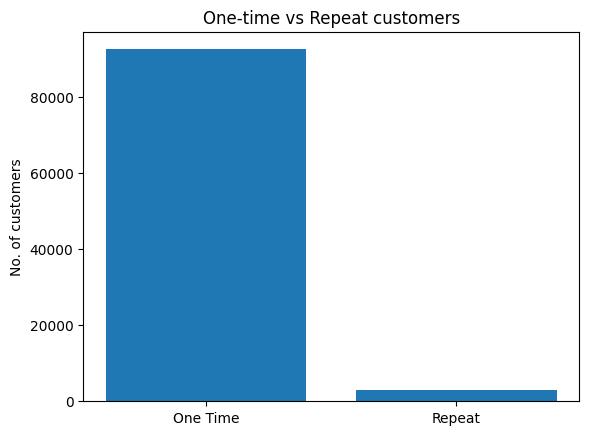

In [45]:
# plotting bar graph for one-time vs repeat customers
plt.bar(['One Time','Repeat'],repeat_counts.values)
plt.ylabel('No. of customers')
plt.title('One-time vs Repeat customers')
plt.show()

In [48]:
top_sellers= seller_sum.sort_values('seller_revenue',ascending=False).head(10)
top_sellers

,seller_id,seller_revenue,seller_order_count
857,4869f7a5dfa277a7dca6462dcf3b52b2,229472.63,1132
1013,53243585a1d6dc2643021fd1853d8905,222776.05,358
881,4a3ca9315b744ce9f8e9374361493884,200472.92,1806
3024,fa1c13f2614d7b5c4749cbc52fecda94,194042.03,585
1535,7c67e1448b00f6e969d365cea6b010ab,187923.89,982
1560,7e93a43ef30c4f03f38b393420bc753a,176431.87,336
2643,da8622b14eb17ae2831f4ac5b9dab84a,160236.57,1314
1505,7a67c85e85bb2ce8582c35f2203ad736,141745.53,1160
192,1025f0e2d44d7041d6cf58b6550e0bfa,138968.55,915
1824,955fee9216a65b617aa5c0531780ce60,135171.70,1287


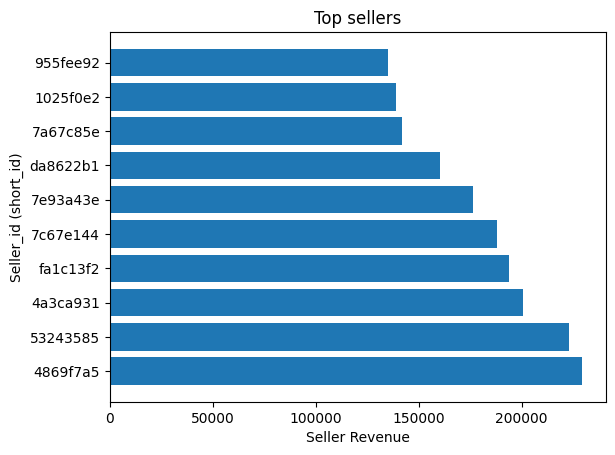

In [54]:
# Plotting horizontal bar chart for top sellers
plt.barh(top_sellers['seller_id'].str[:8], top_sellers['seller_revenue'])
plt.xlabel('Seller Revenue')
plt.ylabel('Seller_id (short_id)')
plt.title('Top sellers')
plt.show()

In [51]:
# Calculating top 10 seller revenue share
top_10_share= (top_sellers['seller_revenue'].sum()/seller_sum['seller_revenue'].sum()*100).round(2)
top_10_share

np.float64(13.15)

**Observations:**
1. Only 3.05% of the customers are repeat buyers which means business relier mostly on new customers
2. 13% of the total revenue are brought by top 10 sellers
3. Why most of the customers are one time buyers needs to be investigated using delivery or reviews in later analysis?


#### 2. Bivariate Analysis
Looking at two column at a time to understand their relation

##### 2.1 Late Delivery vs Review Score

In [ ]:
# merging two tables to group by delivery delay and check the avg. review score
del_rev=delivered.merge(reviews[['order_id','review_score']],on='order_id')
del_rev['is_late']=del_rev['delivery_delay']>0
del_rev.shape

(96359, 9)

In [56]:
# checking is_late (delayed, not_delayed) wise avg review score
avg_review= del_rev.groupby('is_late')['review_score'].mean().round(2)
avg_review

is_late
False    4.29
True     2.27
Name: review_score, dtype: float64

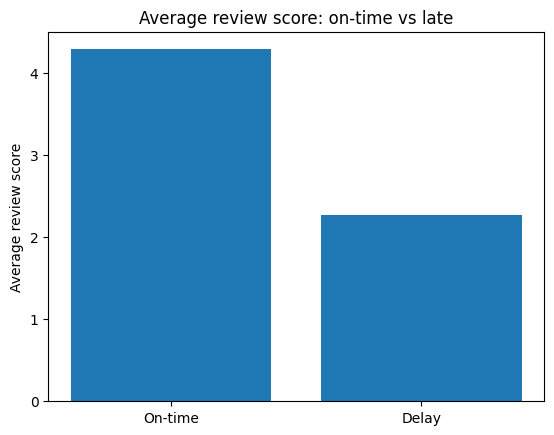

In [57]:
# plotting bar graph for avg review score: on time vs late
plt.bar(['On-time','Delay'],[avg_review[False],avg_review[True]])
plt.ylabel('Average review score')
plt.title('Average review score: on-time vs late')
plt.show()

**Observations:**
1. On-time deliveries have a review score of 4.29 while the delay deliveries have review score of 2.27.
2. It means delay deliveries are strongly linked with customers dis-satisfaction.
3. So reducting the delivery delays should be the main priority.

##### 2.2 Top 10 categories by revenue

In [59]:
# Loading products table, category translation table and order_items table from sql
items= pd.read_sql("select order_id,product_id,price from order_items",db_con)
products = pd.read_sql("select product_id, product_category_name from products",db_con)
translation=pd.read_sql("select * from category_translation",db_con)

In [ ]:
# Joined all three tables using merge to group by category wise revenue
item_cat=items.merge(products,on='product_id').merge(translation, on='product_category_name')
item_cat.shape

(112650, 5)

In [ ]:
# Calculating category wise revenue and then picking top 10 categories
cat_rev=item_cat.groupby('product_category_name_english')['price'].sum()
top_cats=cat_rev.sort_values(ascending=False).head(10)
top_cats

product_category_name_english
health_beauty            1258681.34
watches_gifts            1205005.68
bed_bath_table           1036988.68
sports_leisure            988048.97
computers_accessories     911954.32
furniture_decor           729762.49
cool_stuff                635290.85
housewares                632248.66
auto                      592720.11
garden_tools              485256.46
Name: price, dtype: float64

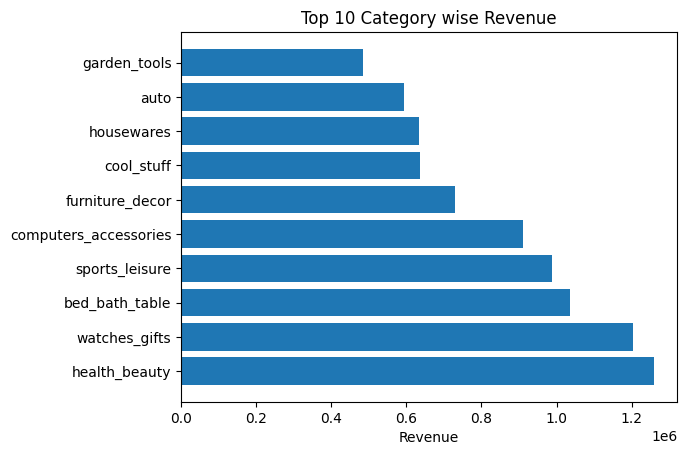

In [63]:
# Plotting horizontal bar chart for category wise revenue
plt.barh(top_cats.index ,top_cats.values)
plt.xlabel('Revenue')
plt.title('Top 10 Category wise Revenue')
plt.show()

In [65]:
# Checking top 10 categories share
((top_cats.sum()/cat_rev.sum())*100).round(2)

np.float64(62.36)

**Observations:**
1. Top category is health_beauty with a overall revenue of 1258681.34.
2. Top 10 categories are contributing 62% of the revenue which is very huge. 
3. So all these categories should be in stock.

##### 2.3 Customers state vs orders and delivery time

In [77]:
# Loading customers tables with necessary columns to join with delivered table
customers=pd.read_sql("select customer_id,customer_state from customers",db_con)
deliv_state=delivered.merge(customers,on='customer_id')
deliv_state.shape

(96476, 8)

In [78]:
# Calculcating top 10 states by number of orders
state_orders=deliv_state.groupby('customer_state')['order_id'].count()
top_10_states=state_orders.sort_values(ascending=False).head(10)
top_10_states

customer_state
SP    40495
RJ    12353
MG    11355
RS     5344
PR     4923
SC     3547
BA     3256
DF     2080
ES     1995
GO     1957
Name: order_id, dtype: int64

In [87]:
top_state=state_orders.sort_values(ascending=False).head(1)
(top_state/state_orders.sum())*100

customer_state
SP    41.97417
Name: order_id, dtype: float64

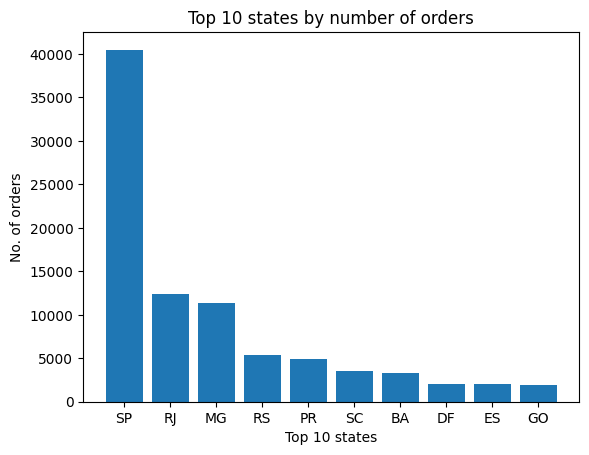

In [76]:
# plotting bar graph for top 10 states by number of orders
plt.bar(top_10_states.index,top_10_states.values)
plt.xlabel('Top 10 states')
plt.ylabel('No. of orders')
plt.title('Top 10 states by number of orders')
plt.show()

In [83]:
# Calculating state wise average delivery days
state_days=deliv_state.groupby('customer_state')['delivery_days'].mean().round().sort_values(ascending=False)
state_days

customer_state
RR    29.0
AP    27.0
AM    26.0
AL    24.0
PA    23.0
AC    21.0
CE    21.0
MA    21.0
SE    21.0
PB    20.0
BA    19.0
RN    19.0
RO    19.0
PI    19.0
MT    18.0
PE    18.0
TO    17.0
ES    15.0
GO    15.0
RS    15.0
RJ    15.0
MS    15.0
SC    14.0
DF    13.0
MG    12.0
PR    12.0
SP     8.0
Name: delivery_days, dtype: float64

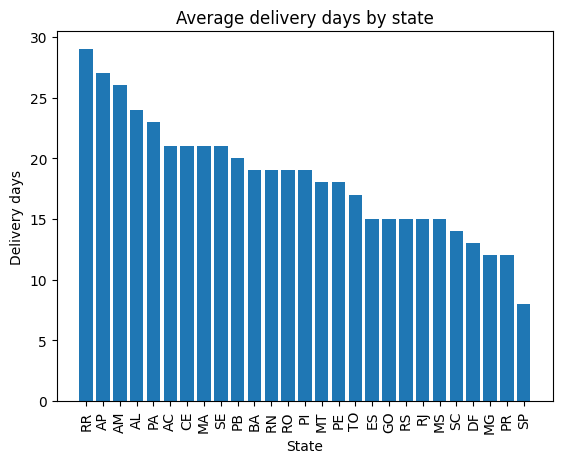

In [86]:
# Plotting bar chart for state wise average delivery days
plt.bar(state_days.index,state_days.values)
plt.xlabel('State')
plt.ylabel('Delivery days')
plt.title('Average delivery days by state')
plt.xticks(rotation=90)
plt.show()

**Observations:**
1. SP is the top state by no. of orders with a share of 41% of total orders.
2. Average delivery is slowest in RR state and fastest in SP state.